In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

START = "2010-01-01"
END = "2026-07-22"

tickers = {
    "Gold": "GC=F",
    "DXY": "DX-Y.NYB",
    "Oil_WTI": "CL=F",
    "US10Y": "^TNX",
    "SP500": "^GSPC",
    "VIX": "^VIX"
}

def robust_close(df: pd.DataFrame, ticker: str) -> pd.Series:
    """Extrahiert die Close-Spalte als 1D-Series, egal ob yfinance
    flache Spalten oder MultiIndex-Spalten zurückgibt."""
    if isinstance(df.columns, pd.MultiIndex):
        # Neuere yfinance-Versionen: Spalten sind (Feld, Ticker)
        close = df["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
    else:
        close = df["Close"]
    close.name = ticker
    return close

raw_data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
    if df.empty:
        print(f"WARNUNG: Keine Daten für {name} ({ticker}) erhalten!")
        continue
    raw_data[name] = robust_close(df, name)
    print(f"{name} ({ticker}): {len(df)} Zeilen geladen")

Gold (GC=F): 4160 Zeilen geladen
DXY (DX-Y.NYB): 4162 Zeilen geladen
Oil_WTI (CL=F): 4161 Zeilen geladen
US10Y (^TNX): 4159 Zeilen geladen
SP500 (^GSPC): 4161 Zeilen geladen
VIX (^VIX): 4162 Zeilen geladen


In [18]:
for name, series in raw_data.items():
    print(name, type(series), series.shape)

Gold <class 'pandas.core.series.Series'> (4160,)
DXY <class 'pandas.core.series.Series'> (4162,)
Oil_WTI <class 'pandas.core.series.Series'> (4161,)
US10Y <class 'pandas.core.series.Series'> (4159,)
SP500 <class 'pandas.core.series.Series'> (4161,)
VIX <class 'pandas.core.series.Series'> (4162,)


In [19]:
# Alle Serien zu einem DataFrame zusammenführen (Index = Datum)
data = pd.DataFrame(raw_data)

# Überblick: wie viele fehlende Werte durch unterschiedliche Handelskalender?
print("Fehlende Werte pro Spalte:")
print(data.isna().sum())
print(f"\nZeitraum: {data.index.min()} bis {data.index.max()}")
print(f"Anzahl Zeilen gesamt: {len(data)}")

# Forward-Fill für Lücken durch abweichende Feiertage/Handelstage
# (z.B. Öl-Markt hat andere Feiertage als Aktienmarkt)
data = data.ffill()

# Verbleibende NaNs am Anfang (falls eine Reihe später startet) droppen
data = data.dropna()

print(f"\nNach Bereinigung: {len(data)} Zeilen, Zeitraum {data.index.min()} bis {data.index.max()}")
data.head()

Fehlende Werte pro Spalte:
Gold       6
DXY        4
Oil_WTI    5
US10Y      7
SP500      5
VIX        4
dtype: int64

Zeitraum: 2010-01-04 00:00:00 bis 2026-07-21 00:00:00
Anzahl Zeilen gesamt: 4166

Nach Bereinigung: 4166 Zeilen, Zeitraum 2010-01-04 00:00:00 bis 2026-07-21 00:00:00


,Gold,DXY,Oil_WTI,US10Y,SP500,VIX
Date,,,,,,
2010-01-04,1117.699951,77.529999,81.510002,3.841,1132.989990,20.040001
2010-01-05,1118.099976,77.620003,81.769997,3.755,1136.520020,19.350000
2010-01-06,1135.900024,77.489998,83.180000,3.808,1137.140015,19.160000
2010-01-07,1133.099976,77.910004,82.660004,3.822,1141.689941,19.059999
2010-01-08,1138.199951,77.470001,82.750000,3.808,1144.979980,18.129999


In [20]:
# Speichern als Zwischenstand für CRISP-DM "Data Understanding"
data.to_csv("gold_exog_raw.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4166 entries, 2010-01-04 to 2026-07-21
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Gold     4166 non-null   float64
 1   DXY      4166 non-null   float64
 2   Oil_WTI  4166 non-null   float64
 3   US10Y    4166 non-null   float64
 4   SP500    4166 non-null   float64
 5   VIX      4166 non-null   float64
dtypes: float64(6)
memory usage: 227.8 KB


1. Business Understanding

2. Data Exploration

In [21]:
# Zwischenstand laden (falls du in neuer Session weiterarbeitest)
# data = pd.read_csv("gold_exog_raw.csv", index_col=0, parse_dates=True)

# --- 3.1 Deskriptive Statistik ---
print("Deskriptive Statistik:")
print(data.describe().T)

print("\nDatentypen & Vollständigkeit:")
print(data.info())

Deskriptive Statistik:
          count         mean          std          min          25%  \
Gold     4166.0  1762.165937   785.195769  1050.800049  1272.599976   
DXY      4166.0    92.947708     9.284817    72.930000    82.732502   
Oil_WTI  4166.0    71.870468    20.743246   -37.630001    55.382499   
US10Y    4166.0     2.662518     1.035842     0.499000     1.877250   
SP500    4166.0  3084.499673  1646.193903  1022.580017  1843.184998   
VIX      4166.0    18.438392     6.789044     9.140000    13.840000   

                 50%          75%          max  
Gold     1548.250000  1864.174957  5318.399902  
DXY        95.475002    99.290001   114.110001  
Oil_WTI    71.779999    88.757502   123.699997  
US10Y       2.500500     3.491750     4.988000  
SP500    2662.845093  4183.765015  7609.779785  
VIX        16.770000    21.080000    82.690002  

Datentypen & Vollständigkeit:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4166 entries, 2010-01-04 to 2026-07-21
Data columns 

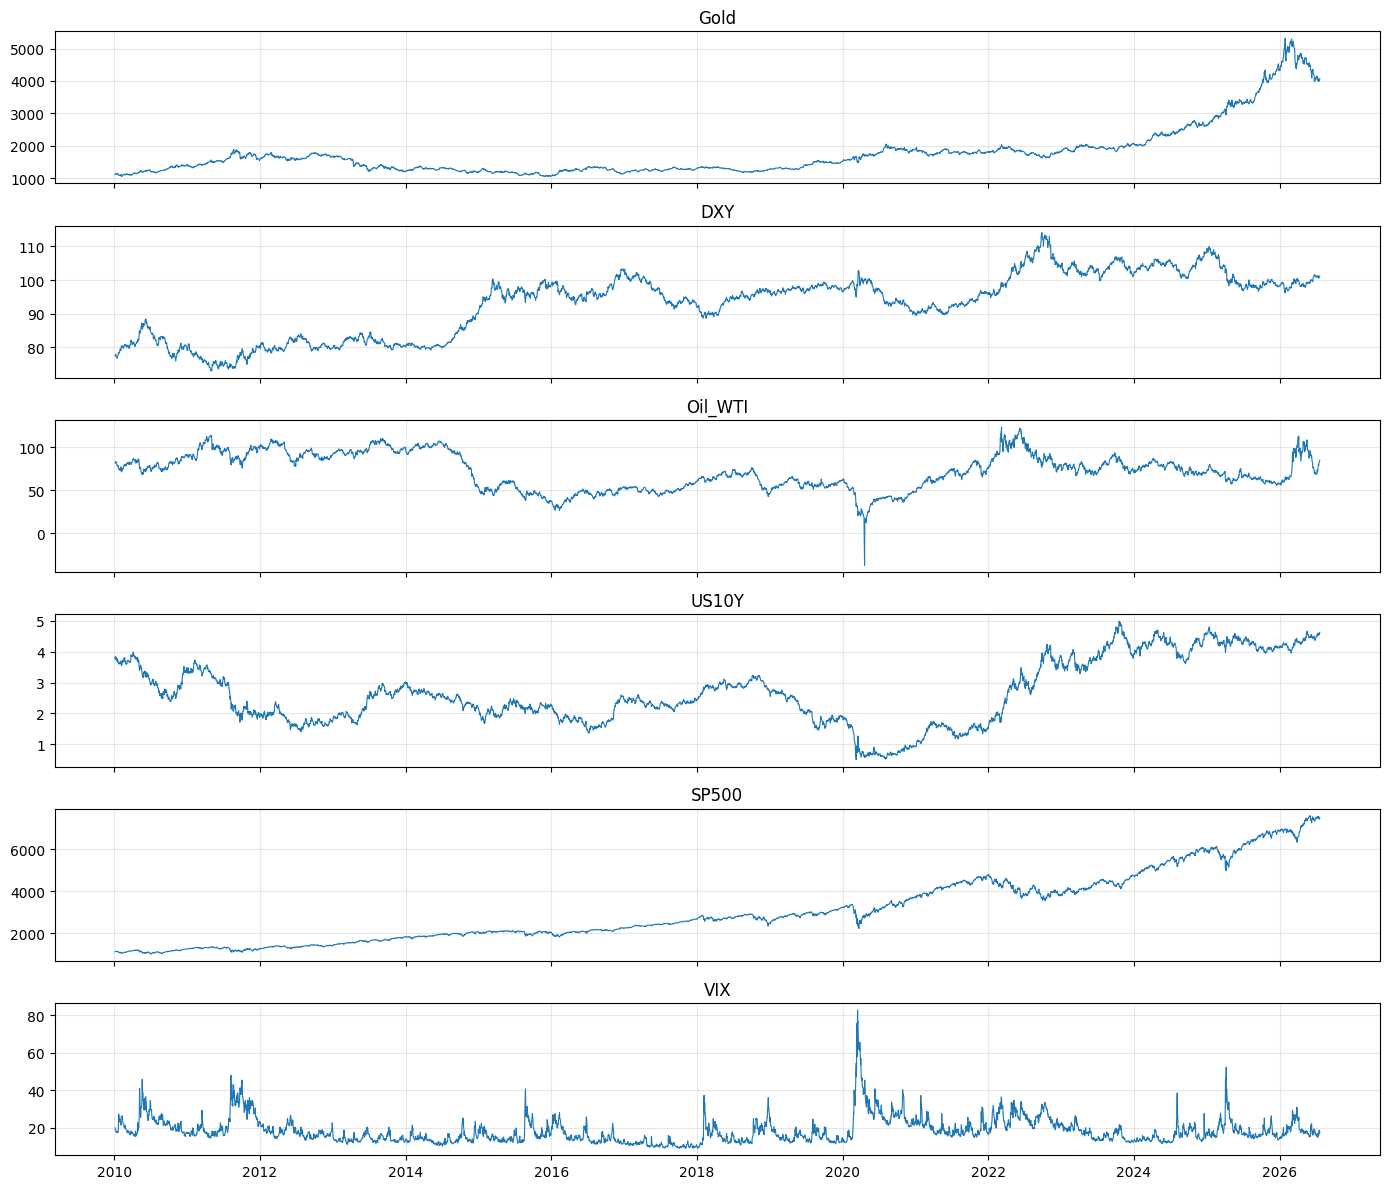

In [22]:
# --- 3.2 Zeitreihenplots: Rohwerte ---
fig, axes = plt.subplots(len(data.columns), 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, data.columns):
    ax.plot(data.index, data[col], linewidth=0.8)
    ax.set_title(col)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("timeseries_overview.png", dpi=100)
plt.show()

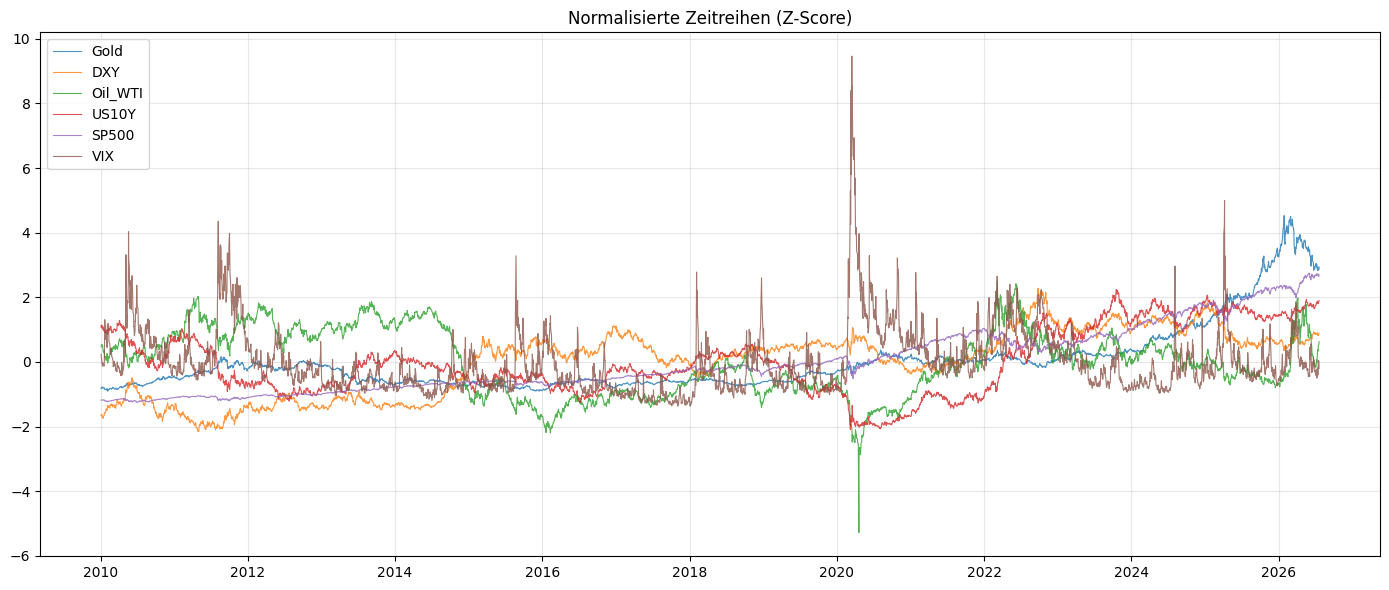

In [23]:
# --- 3.3 Normalisierte Übersicht (alle Reihen vergleichbar auf einer Skala) ---
# Sinnvoll, um Ko-Bewegungen visuell zu erkennen (z.B. Gold vs. DXY invers)
data_normalized = (data - data.mean()) / data.std()

plt.figure(figsize=(14, 6))
for col in data_normalized.columns:
    plt.plot(data_normalized.index, data_normalized[col], label=col, linewidth=0.8, alpha=0.8)
plt.legend(loc="upper left")
plt.title("Normalisierte Zeitreihen (Z-Score)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("timeseries_normalized.png", dpi=100)
plt.show()

In [24]:
# --- 3.4 Stationaritätstests (ADF) — essenziell für ARIMA! ---
from statsmodels.tsa.stattools import adfuller

def adf_test(series: pd.Series, name: str):
    result = adfuller(series.dropna())
    return {
        "Variable": name,
        "ADF-Statistik": result[0],
        "p-Wert": result[1],
        "Stationär (p<0.05)": result[1] < 0.05
    }

adf_results = pd.DataFrame([adf_test(data[col], col) for col in data.columns])
print("ADF-Test auf Rohdaten (Level):")
print(adf_results.to_string(index=False))

ADF-Test auf Rohdaten (Level):
Variable  ADF-Statistik   p-Wert  Stationär (p<0.05)
    Gold       0.452625 0.983360               False
     DXY      -1.708583 0.426696               False
 Oil_WTI      -2.517860 0.111189               False
   US10Y      -1.203125 0.672250               False
   SP500       1.932563 0.998579               False
     VIX      -5.646193 0.000001                True


In [25]:
# --- 3.5 ADF-Test auf 1. Differenzen (log-returns) ---
# Finanzzeitreihen sind auf Level fast immer nicht-stationär (Random Walk)
# -> log-Renditen prüfen, da ARIMA i.d.R. auf differenzierten/stationären Reihen arbeitet
log_returns = np.log(data / data.shift(1)).dropna()

adf_results_diff = pd.DataFrame([adf_test(log_returns[col], col) for col in log_returns.columns])
print("\nADF-Test auf log-Differenzen:")
print(adf_results_diff.to_string(index=False))

c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)



ADF-Test auf log-Differenzen:
Variable  ADF-Statistik       p-Wert  Stationär (p<0.05)
    Gold     -66.509229 0.000000e+00                True
     DXY     -63.694866 0.000000e+00                True
 Oil_WTI     -11.795527 9.599632e-22                True
   US10Y      -9.818217 5.425481e-17                True
   SP500     -13.870420 6.480208e-26                True
     VIX     -25.589157 0.000000e+00                True


### Interpretation

- **Alle Preis-Level-Reihen** (Gold, DXY, Oil_WTI, US10Y, SP500) sind **nicht-stationär** (p-Werte deutlich über 0.05). Dies entspricht dem theoretisch erwarteten Random-Walk-Verhalten von Finanzzeitreihen und bestätigt, dass für ein ARIMA-/SARIMAX-Modell eine **Differenzierung (d=1)** notwendig ist.
- **VIX** ist bereits auf Level-Basis **stationär** (p < 0.001), was inhaltlich plausibel ist: Der VIX ist ein mean-reverting Volatilitätsindex, der um ein langfristiges Niveau schwankt, statt wie ein Preis zu "wandern".
- **Alle log-Renditen sind stationär** (p ≈ 0 bzw. hochsignifikant), womit die Differenzierung erfolgreich Stationarität herstellt.

### Konsequenz für die Modellierung

Für das SARIMAX-Modell ergibt sich ein **Stationaritäts-Mismatch**: Während Gold, DXY, Oil_WTI, US10Y und SP500 als **log-Renditen/Differenzen** eingebunden werden sollten, kann VIX ggf. **auf Level-Basis** als exogene Variable verwendet werden. Dies wird in der Data-Preparation-Phase entsprechend berücksichtigt.

### Korrelationsanalyse

Zwei Reihen mit gemeinsamem Trend (z. B. beide steigen über Jahre) zeigen oft hohe Korrelation, obwohl kein echter Zusammenhang besteht ("Scheinkorrelation"/spurious regression, Granger & Newbold 1974). Die Korrelation der Renditen ist daher die methodisch validere Grundlage, um zu entscheiden, welche exogenen Variablen später ins SARIMAX-Modell sollen.

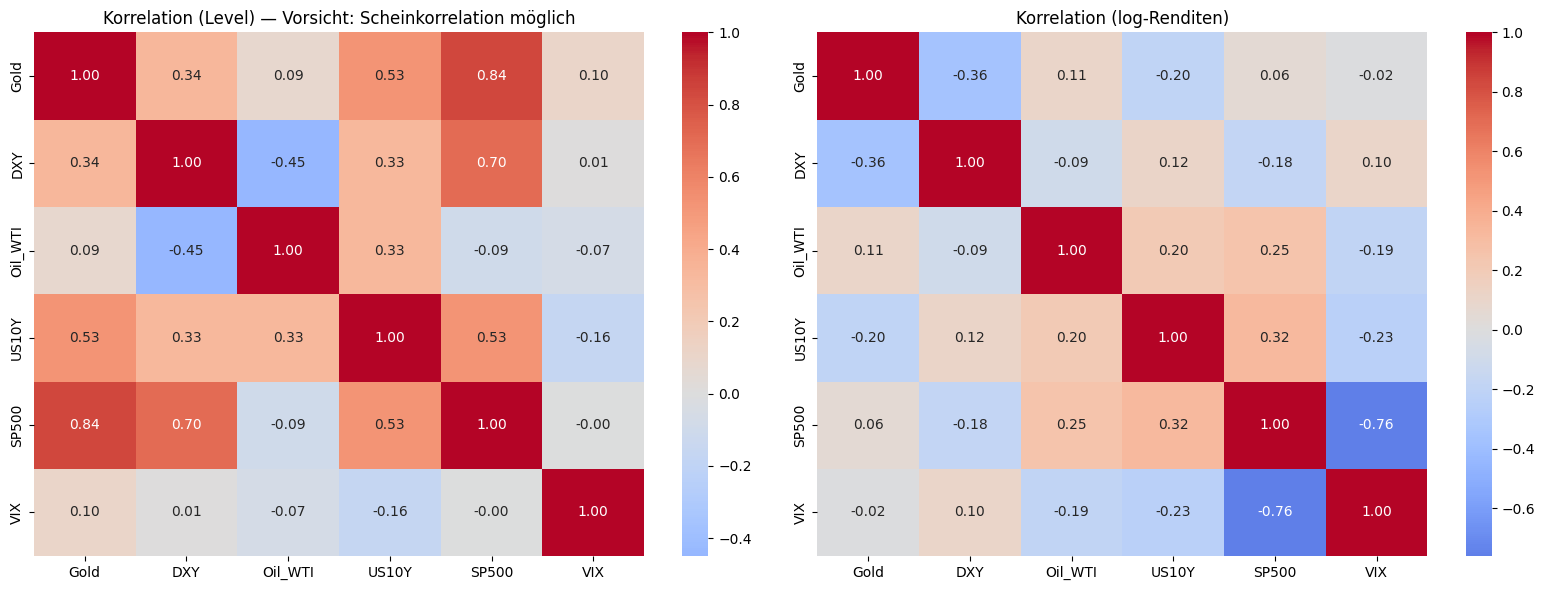

In [26]:
# --- 3.6 Korrelationsmatrix ---
# a) Level-Korrelation (kann durch gemeinsamen Trend verzerrt sein - Scheinkorrelation!)
corr_level = data.corr()

# b) Korrelation der log-Renditen (methodisch sauberer für Kausalzusammenhänge)
corr_returns = log_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_level, annot=True, cmap="coolwarm", center=0, ax=axes[0], fmt=".2f")
axes[0].set_title("Korrelation (Level) — Vorsicht: Scheinkorrelation möglich")

sns.heatmap(corr_returns, annot=True, cmap="coolwarm", center=0, ax=axes[1], fmt=".2f")
axes[1].set_title("Korrelation (log-Renditen)")

plt.tight_layout()
plt.savefig("correlation_matrices.png", dpi=100)
plt.show()


### Interpretation

- **DXY** zeigt mit **-0.36** die stärkste Korrelation zu Gold und bestätigt den theoretisch erwarteten inversen Dollar-Gold-Zusammenhang am deutlichsten. Klarer Kandidat für das Modell.
- **US10Y** korreliert mit **-0.20** ebenfalls im erwarteten (negativen) Vorzeichen über den Realzins-Kanal, wenn auch schwächer. Bleibt ein sinnvoller Regressor, da der Zusammenhang theoretisch gut begründet ist, auch wenn die reine Korrelation moderat ausfällt.
- **Oil_WTI (0.11)** zeigt nur eine sehr schwache positive Korrelation. Ein gewisser Zusammenhang über den gemeinsamen Inflations-/Rohstoffkanal ist denkbar, aber statistisch schwach ausgeprägt.
- **SP500 (0.06)** und **VIX (-0.02)** zeigen praktisch **keine lineare Korrelation** zu den Gold-Renditen in diesem Datensatz. Das ist insofern bemerkenswert, als beide Variablen in der Literatur oft als Risk-on/Risk-off- bzw. Safe-Haven-Indikatoren für Gold diskutiert werden – hier liefert die einfache lineare Korrelation dafür aber keine Evidenz.

### Konsequenz für die Variablenauswahl

- **DXY und US10Y** erscheinen auf Basis dieser Analyse als die **stärksten Kandidaten** für exogene Regressoren im SARIMAX-Modell.
- **Oil_WTI, SP500 und VIX** zeigen in der linearen Korrelation kaum Erklärungskraft. Das schließt sie nicht zwangsläufig aus (nicht-lineare oder zeitverzögerte Effekte sind mit einer einfachen Korrelation nicht erfassbar), sollte aber in der Data-Preparation-Phase kritisch reflektiert werden – z. B. über Granger-Kausalitätstests oder Lag-Analysen, bevor sie final ins Modell aufgenommen werden.
- Da die Korrelationen zwischen den exogenen Kandidaten selbst (DXY, US10Y, Oil, SP500, VIX) durchweg niedrig sind, ist das **Multikollinearitätsrisiko gering** – ein zusätzlicher VIF-Check in der Data-Preparation-Phase ist dennoch empfehlenswert, um dies formal abzusichern.

## 3. Data Preperation

In [27]:
# --- 4.1 Zielvariable und Regressoren transformieren ---
# Alle gewählten Variablen sind Preis-Level -> log-Renditen (siehe ADF-Test, Abschnitt 3.5)

model_data = pd.DataFrame(index=log_returns.index)

model_data["Gold_ret"] = log_returns["Gold"]
model_data["DXY_ret"] = log_returns["DXY"]
model_data["US10Y_ret"] = log_returns["US10Y"]
model_data["Oil_ret"] = log_returns["Oil_WTI"]

model_data = model_data.dropna()
print(f"Finaler Modell-Datensatz: {model_data.shape}")
model_data.head()

Finaler Modell-Datensatz: (4163, 4)


,Gold_ret,DXY_ret,US10Y_ret,Oil_ret
Date,,,,
2010-01-05,0.000358,0.001160,-0.022644,0.003185
2010-01-06,0.015795,-0.001676,0.014016,0.017097
2010-01-07,-0.002468,0.005405,0.003670,-0.006271
2010-01-08,0.004491,-0.005664,-0.003670,0.001088
2010-01-11,0.010922,-0.006085,0.002623,-0.002783


In [28]:
# --- 4.2 Multikollinearität prüfen (VIF) ---
# Formale Absicherung, dass die 3 gewählten Regressoren sich nicht zu stark überlappen
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

exog_candidates = model_data.drop(columns=["Gold_ret"])
exog_with_const = add_constant(exog_candidates)

vif_data = pd.DataFrame({
    "Variable": exog_with_const.columns,
    "VIF": [variance_inflation_factor(exog_with_const.values, i) for i in range(exog_with_const.shape[1])]
})
print(vif_data[vif_data["Variable"] != "const"].to_string(index=False))

 Variable      VIF
  DXY_ret 1.028908
US10Y_ret 1.063697
  Oil_ret 1.058946


alle VIFs liegen nahe 1.0 (Richtwert für Unbedenklichkeit: <5, oft sogar <2.5 gefordert). Das bestätigt formal, was die Korrelationsmatrix schon andeutete: DXY, US10Y und Oil_WTI liefern weitgehend unabhängige Information, keine Multikollinearitätsprobleme im Modell zu erwarten.

In [29]:
# --- 4.3 Finale Variablenauswahl ---
final_exog_vars = ["DXY_ret", "US10Y_ret", "Oil_ret"]
print(f"Final gewählte exogene Variablen: {final_exog_vars}")

Final gewählte exogene Variablen: ['DXY_ret', 'US10Y_ret', 'Oil_ret']


In [30]:
# --- 4.4 Train-Test-Split (zeitlich, kein Shuffle!) ---
train_size = int(len(model_data) * 0.85)

train = model_data.iloc[:train_size]
test = model_data.iloc[train_size:]

y_train, y_test = train["Gold_ret"], test["Gold_ret"]
X_train, X_test = train[final_exog_vars], test[final_exog_vars]

print(f"Train: {train.index.min()} bis {train.index.max()} ({len(train)} Zeilen)")
print(f"Test:  {test.index.min()} bis {test.index.max()} ({len(test)} Zeilen)")

Train: 2010-01-05 00:00:00 bis 2024-01-26 00:00:00 (3538 Zeilen)
Test:  2024-01-29 00:00:00 bis 2026-07-21 00:00:00 (625 Zeilen)


### 5. Modeling

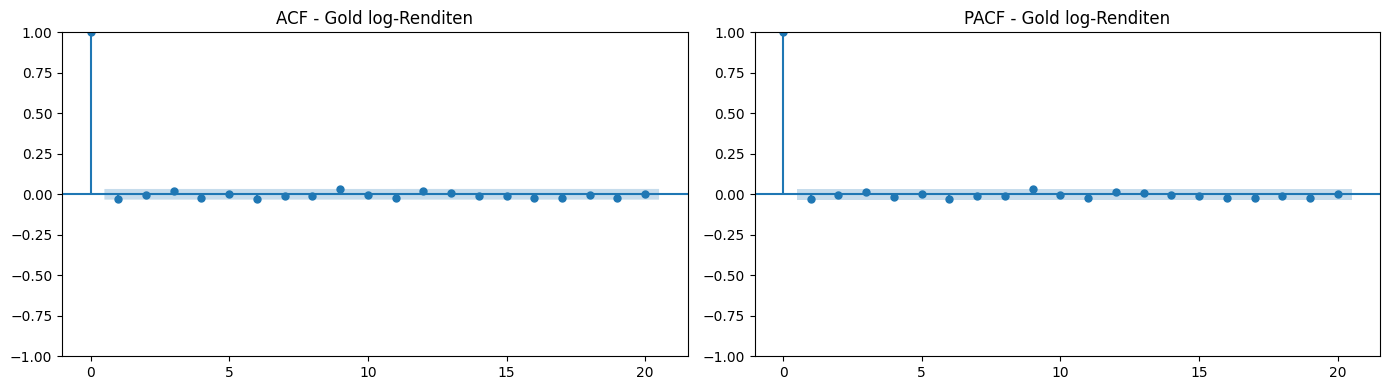

In [31]:
# --- 5.1 ACF/PACF zur Bestimmung der ARIMA-Ordnung (p, q) ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_train, lags=20, ax=axes[0])
axes[0].set_title("ACF - Gold log-Renditen")
plot_pacf(y_train, lags=20, ax=axes[1])
axes[1].set_title("PACF - Gold log-Renditen")
plt.tight_layout()
plt.savefig("acf_pacf_gold.png", dpi=100)
plt.show()

In [35]:
# --- 5.2 Automatische Ordnungssuche (ergänzend zur visuellen ACF/PACF-Analyse) ---
# pmdarima automatisiert die Grid-Search über (p,d,q) via AIC
import pmdarima as pm

auto_model = pm.auto_arima(
    y_train,
    X=X_train,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=0,  # bereits stationär (log-Renditen), keine weitere Differenzierung nötig
    seasonal=False,  # Renditen zeigen i.d.R. keine klare Saisonalität; ggf. später prüfen
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-23183.414, Time=0.57 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-23198.204, Time=0.33 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-23199.092, Time=0.24 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-23198.355, Time=0.26 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-23198.843, Time=0.59 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-23199.535, Time=0.76 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-23195.147, Time=1.85 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-23195.653, Time=0.68 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-23197.533, Time=0.77 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-23197.849, Time=0.29 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-23194.996, Time=0.80 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-23200.211, Time=2.42 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-23199.413, Time=0.60 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-23198.918, Time=0.54 sec
 ARIM

In [36]:
# --- 5.3 SARIMAX-Modell mit statsmodels fitten ---
# statsmodels bevorzugt, da es umfangreichere Diagnostik & Konfidenzintervalle liefert
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = auto_model.order  # (p, d, q) aus 5.2 übernehmen

sarimax_model = SARIMAX(
    y_train,
    X=X_train,
    order=order,
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['X']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                               SARIMAX Results                                
Dep. Variable:               Gold_ret   No. Observations:                 3538
Model:               SARIMAX(1, 0, 2)   Log Likelihood               11242.027
Date:                Wed, 22 Jul 2026   AIC                         -22476.053
Time:                        19:23:58   BIC                         -22451.368
Sample:                             0   HQIC                        -22467.248
                               - 3538                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6061      1.169     -0.519      0.604      -2.897       1.685
ma.L1          0.5757      1.167      0.493      0.622      -1.712       2.864
ma.L2         -0.0245      0.032     -0.755      0.4

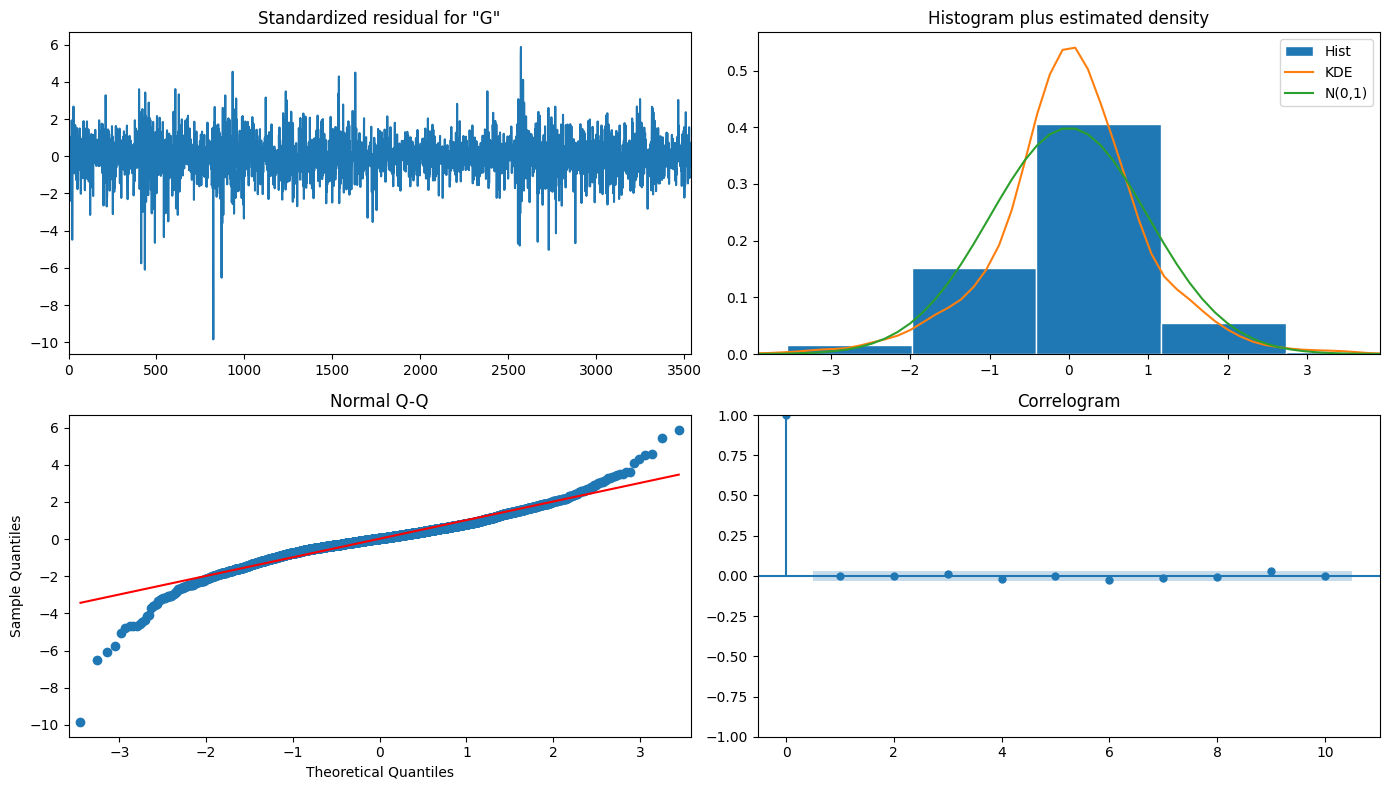


Ljung-Box-Test (H0: keine Autokorrelation in Residuen):
    lb_stat  lb_pvalue
10  9.03074   0.529189


In [37]:
# --- 5.4 Residuen-Diagnostik ---
# Wichtig: Residuen sollten wie weißes Rauschen aussehen (keine Autokorrelation, ~normalverteilt)
sarimax_fit.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.savefig("sarimax_diagnostics.png", dpi=100)
plt.show()

# Ljung-Box-Test auf Residuen-Autokorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(sarimax_fit.resid, lags=[10], return_df=True)
print("\nLjung-Box-Test (H0: keine Autokorrelation in Residuen):")
print(lb_test)

In [38]:
# --- 6.1 Prognose auf dem Testset ---
n_test = len(y_test)

forecast_result = sarimax_fit.get_forecast(steps=n_test, exog=X_test)
y_pred = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

y_pred.index = y_test.index
conf_int.index = y_test.index

c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\fschm\Documents\AI_BP_Repo\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [39]:
# --- 6.2 Benchmark-Modell: Naive Forecast (Random-Walk-Annahme) ---
# Für Finanzmarktrenditen ist die Benchmark "morgen = 0% Rendite" (bzw. Mittelwert Trainingsset)
# Ein sinnvolles Modell sollte diese simple Baseline schlagen
y_naive = pd.Series(y_train.mean(), index=y_test.index)

In [40]:
# --- 6.3 Fehlermetriken: SARIMAX vs. Naive Benchmark ---
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label:20s} RMSE: {rmse:.6f}   MAE: {mae:.6f}")
    return rmse, mae

print("Out-of-Sample-Fehlermetriken (log-Renditen):")
rmse_sarimax, mae_sarimax = evaluate(y_test, y_pred, "SARIMAX")
rmse_naive, mae_naive = evaluate(y_test, y_naive, "Naive (Mittelwert)")

improvement_rmse = (1 - rmse_sarimax / rmse_naive) * 100
print(f"\nRMSE-Verbesserung ggü. Naive: {improvement_rmse:.1f}%")

Out-of-Sample-Fehlermetriken (log-Renditen):
SARIMAX              RMSE: 0.014104   MAE: 0.009914
Naive (Mittelwert)   RMSE: 0.014092   MAE: 0.009891

RMSE-Verbesserung ggü. Naive: -0.1%


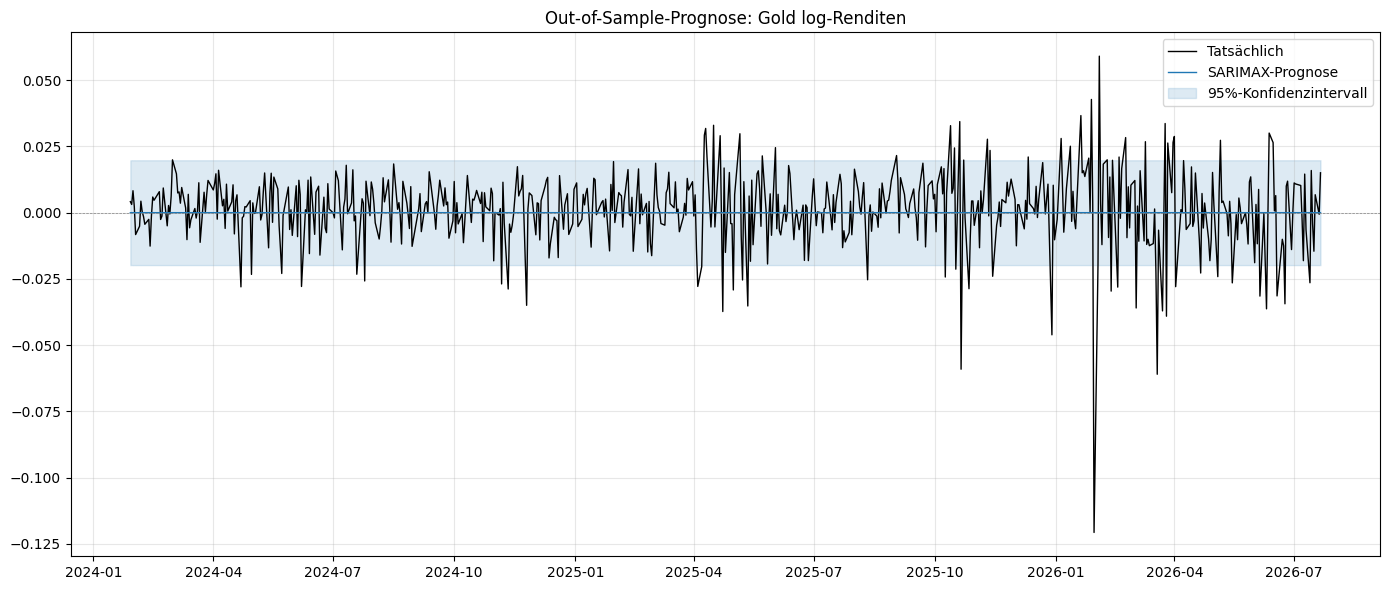

In [41]:
# --- 6.4 Visualisierung: Prognose vs. tatsächliche Werte ---
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Tatsächlich", color="black", linewidth=1)
plt.plot(y_test.index, y_pred, label="SARIMAX-Prognose", color="tab:blue", linewidth=1)
plt.fill_between(y_test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color="tab:blue", alpha=0.15, label="95%-Konfidenzintervall")
plt.axhline(0, color="grey", linewidth=0.5, linestyle="--")
plt.legend()
plt.title("Out-of-Sample-Prognose: Gold log-Renditen")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_vs_actual.png", dpi=100)
plt.show()

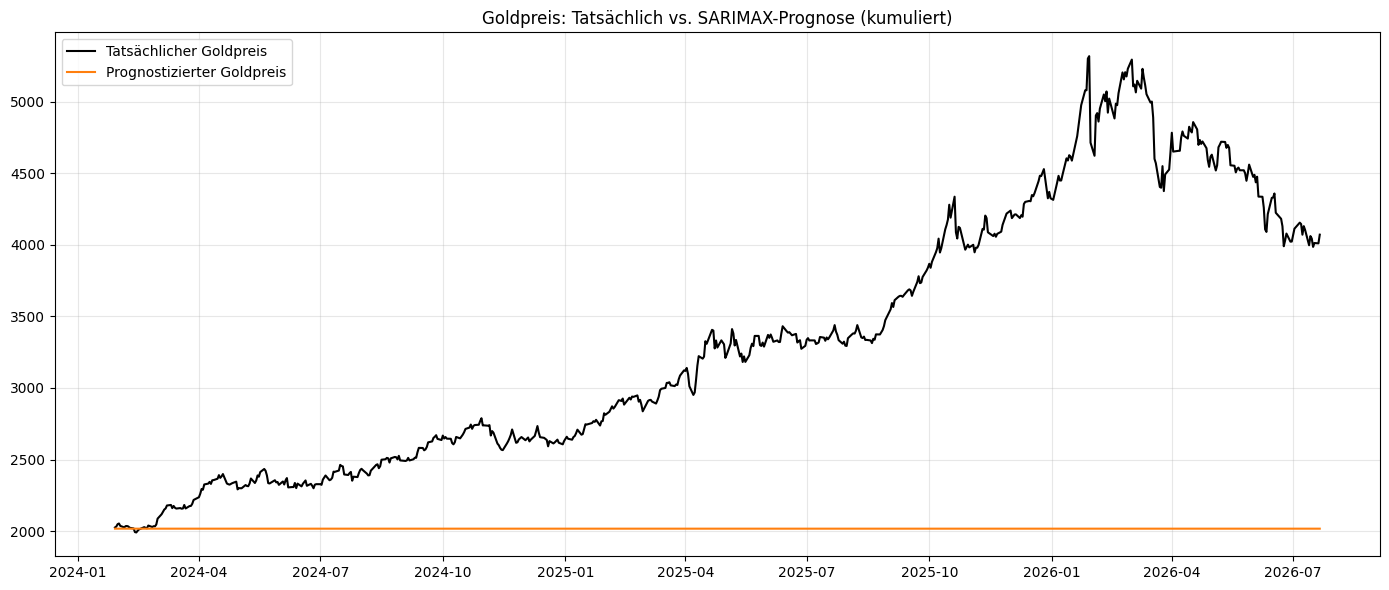

In [42]:
# --- 6.5 Rückrechnung auf Preis-Niveau (kumulative Renditen -> Preispfad) ---
# Renditen sind für Modell-Fit wichtig, aber ein Preis-Chart ist inhaltlich anschaulicher
last_train_price = data["Gold"].loc[y_train.index[-1]]

cum_actual_price = last_train_price * np.exp(y_test.cumsum())
cum_pred_price = last_train_price * np.exp(y_pred.cumsum())

plt.figure(figsize=(14, 6))
plt.plot(cum_actual_price.index, cum_actual_price, label="Tatsächlicher Goldpreis", color="black")
plt.plot(cum_pred_price.index, cum_pred_price, label="Prognostizierter Goldpreis", color="tab:orange")
plt.legend()
plt.title("Goldpreis: Tatsächlich vs. SARIMAX-Prognose (kumuliert)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_price_level.png", dpi=100)
plt.show()